# Parte prática do Card 11

As seções do curso abordou como lidar com dados do mundo real, desde a infraestrutura <i>Data Warehousing</i> até a preparação de dados. Nestas seções, também foi apresentado três tipos de algoritmos (k-NN, Q-Learning e PCA) e métricas de para avaliar eles.  
Nesta prática, preferi abordar um dos 3 algoritmos e realizar uma avaliação do seu desempenho. Irei seguir a mesma sequência utilizada no curso, que seria:  
  
**Carregamento e exploração dos dados:** Carregar o <i>dataset</i>, ver quantos dados ausentes existem e em quais colunas.  
**Limpeza e Aplicação da Engenharia de Recursos:** Identificar e tratar os dados ausentes. Nesta etapa, irei usar k-NN para para imputar a coluna de idade, e para colunas categóricas com poucos dados ausentes, substituir pela moda e codificar colunas categóricas como sexo (masculino e feminino para 0 e 1). 
**Treino:** Treinar o k-NN.  
**Avaliação:** Gerar a matriz de confusão e calcular precisão, <i>recall</i> e F1 Score.  
  
Estarei utilizando o conjunto de dados Titanic, ele vem junto do <i>Seaborn</i>. Irei treinar o modelo para prever se o passageiro sobreviveu ou não.

## Carregamento dos Dados

Eu escolhi o <i>dataset</i> Titanic, ele vem junto do <i>Seaborn</i>.

In [21]:
import numpy as np
import pandas as pd

titanic = pd.read_csv('titanic.csv', sep=',')
df = pd.DataFrame(titanic)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Agora vou ver a quantidade de linha este dataset contém e contar quantos dados ausentes há para cada coluna.

In [2]:
# As colunas deste dataset
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Observando o <i>DataFrame</i>, ele contem 15 colunas, sendo elas:  
- **survived:** Indica se o passageiro sobreviveu (sim = 1, não = 0).
- **pclass:** Indica a qual classe o passageiro estava, basicamente, status socioeconômico (1 = primeira classe, 2 = segunda classe e 3 = terceira classe, acredito que seja óbvio que conforme menor o número, mais rico ele era).
- **sex:** Gênero do passageiro.
- **age:** Idade do passageiro.
- **sibsp:** Números de irmãos ou cônjuges a bordo (esse eu tive que pesquisar, sib para siblings e sp para spouses, juntos fica sibsp).
- **parch:** Número de pais ou filhos a bordo.
- **fare:** Preço que o passageiro pagou pela passagem.
- **embarked:** Porto que que o passageiro embarcou (C = Cherbourg, Q = Queenstown, S = Southampton).
- **class:** Mesma informação que a **pclass**, porém em formato categórico (primeira, segunda, terceira).
- **who:** Categoria do passageiro (homem, mulher, criança).
- **adult_male:** Booleano que indica se era um homem adulto.
- **deck:** Convés onde o passageiro estava acomodado (A, B, C, D, E, F, G).
- **embark_town:** Nome da cidade de embarque.
- **alive:** Indica de o passageiro sobreviveu.
- **alone:** Indica se o passageiro estava sozinho.

In [22]:
# Quantidade de linhas neste dataset
df.index

RangeIndex(start=0, stop=891, step=1)

## Etapa de Limpeza

Agora, para continuar irei realizar uma preparação de limpeza desses dados.  
Observando abaixo, há bastantes dados ausentes para a idade dos passageiros e para o convés em que o passageiro estava acomodado. Então, para não apagar essas linhas, vou usar k-NN para completar a coluna `age` e remover as colunas `class`, `alive`, `embark_town`, `embarked`, pois elas são irrelevantes, afinal elas se repetem (com formatos diferentes).  
As colunas `who` e `adult_male` também não fazem sentido manter, posso ter essas informações analisando `age` e `sex`.  
Também notei que `deck` seria ruim manter, falta bastante dados nela e também se eu substituisse pela moda, a moda é C, poderia enviessar os resultados.

In [23]:
# Vai fazer uma contagem para cada coluna e mostrar a quantidade de valores NaN nelas
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [24]:
# Remove as 7 colunas (alive, class, embark_town, who, adult_male, embarked, deck)
df.drop(columns= ['alive', 'class', 'who', 'adult_male', 'embark_town', 'embarked', 'deck'], inplace=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone
0,0,3,male,22.0,1,0,7.2500,False
1,1,1,female,38.0,1,0,71.2833,False
2,1,3,female,26.0,0,0,7.9250,True
3,1,1,female,35.0,1,0,53.1000,False
4,0,3,male,35.0,0,0,8.0500,True


Para explicar o que foi feito acima, eu removi algumas colunas que seriam irrelevantes para o treinamento.  
As colunas alive, class são categóricas, não vai ajudar, já que vou usar k-NN.  
As colunas who, adult_male são irrelevantes, já que posso saber dessas informações se analisar as colunas sex e age.  
A coluna deck iria aumentar o viés do modelo, se eu trocasse pela moda, a maioria dos dados faltantes irão ser "C".  
E as colunas embark_town, embarked são irrelevantes.
Agora para a coluna de idade, irei usar o k-NN para preencher as idades faltantes.  
Primeiro separarei em dois <i>dataframes</i>, um para os passageiros com idade e outro para os sem idade.  
Para continuar, eu iria precisar normalizar alguns dados, as colunas `pclass`, `sibsp`, `parch` e `fare`.

In [25]:
# Vou criar duas cataegorias, um com os passageiros com idade e outro para os que tem a idade faltando
# Adicionei o .copy() para remover os warnings que havia dado, basicamente, os warnings era porque esses dois abaixo são
# Fatias do dataframe original e não outros dataframes independentes
com_idade = df[df['age'].notna()].copy()
sem_idade = df[df['age'].isna()].copy()

# Agora irei precisar normalizar os dados das colunas pclass, fare, sibsp e patch
colunas_distancia = ['pclass', 'fare', 'sibsp', 'parch']

for coluna in colunas_distancia:
    # Pega o valor maximo e minimo do dataframe original
    valor_max = df[coluna].max()
    valor_min = df[coluna].min()
    # Vai criar uma coluna nova com os dados normalizados, em uma escala de 0 a 1
    # a lógica da função é a mesma que a do curso, mas aqui eu não fiz em uma função lambda
    com_idade[coluna + '_norm'] = (com_idade[coluna] - valor_min) / (valor_max - valor_min)
    sem_idade[coluna + '_norm'] = (sem_idade[coluna] - valor_min) / (valor_max - valor_min)

print(com_idade.head())
print(sem_idade.head())

   survived  pclass     sex   age  sibsp  parch     fare  alone  pclass_norm  \
0         0       3    male  22.0      1      0   7.2500  False          1.0   
1         1       1  female  38.0      1      0  71.2833  False          0.0   
2         1       3  female  26.0      0      0   7.9250   True          1.0   
3         1       1  female  35.0      1      0  53.1000  False          0.0   
4         0       3    male  35.0      0      0   8.0500   True          1.0   

   fare_norm  sibsp_norm  parch_norm  
0   0.014151       0.125         0.0  
1   0.139136       0.125         0.0  
2   0.015469       0.000         0.0  
3   0.103644       0.125         0.0  
4   0.015713       0.000         0.0  
    survived  pclass     sex  age  sibsp  parch     fare  alone  pclass_norm  \
5          0       3    male  NaN      0      0   8.4583   True          1.0   
17         1       2    male  NaN      0      0  13.0000   True          0.5   
19         1       3  female  NaN      0     

Agora que tenho que removi as colunas desnecessárias e a alguns dados normalizados, vou usar k-NN para imputar os dados ausentes da coluna de idade.  
No curso, o professor divide em duas etapas, uma para calcular a distância e outra que é o algoritmo, irei reutilizar as funções da aula e modificá-las de acordo com o que eu precisar.

In [26]:
from scipy.spatial import distance

def calc_distancia(a, b):
    # Aqui não faz sentido usar o calculo baseado na similiaridade do cosseno
    # Eu vou usar a distância euclidiana, já que a e b vão ser uma array com as colunas normalizadas
    return distance.euclidean(a, b)

def pegar_vizinhos_idade(passageiro_sem_idade, com_idade, K):
    distancias = []

    # Essa parte da função vai sair diferente da aula, eu não armazenei em um dict, então vou precisar do indice
    # para navegar pelo dataframe, i é indice e outro_passageiro é a Series
    for i, outro_passageiro in com_idade.iterrows():
        colunas_normalizadas = ['pclass_norm', 'fare_norm', 'sibsp_norm', 'parch_norm']
        dist = calc_distancia(passageiro_sem_idade[colunas_normalizadas], outro_passageiro[colunas_normalizadas])
        distancias.append((outro_passageiro['age'], dist))

    # Orderna os resultados
    distancias.sort(key=lambda x: x[1])
    # Pegar os K-vizinhos para calcular a média de idade
    k_vizinhos = distancias[:K]
    idade_imputada = np.mean([vizinho[0] for vizinho in k_vizinhos])
    return idade_imputada

Agora que tenho como calcular a distância dos K vizinhos, eles vão pegar as idades dos K vizinhos e calcular a média, essa média vair ser o média dos que estão com a idade faltando.

In [67]:
for i, passageiro in sem_idade.iterrows():
    # Para cada passageiro sem a idade trocar pela idade imputada
    # Novamente, eu preciso de um indice para navegar pelo dataframe, já que que eu não criei um dict para eles
    # Neste caso, vou pegar os 20 vizinhos
    df.loc[i, 'age'] = pegar_vizinhos_idade(passageiro, com_idade, 10)

Agora temos os dados limpos e completas, agora vou só substituir a coluna `sex` com dados numéricos, 1 para homem e 0 para mulher. Para isso, vou usar o `LabelEncoder` do Scikit-learn.  

In [50]:
from sklearn.preprocessing import LabelEncoder

df['sex'] = LabelEncoder().fit_transform(df['sex'])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone
0,0,3,1,22.0,1,0,7.2500,False
1,1,1,0,38.0,1,0,71.2833,False
2,1,3,0,26.0,0,0,7.9250,True
3,1,1,0,35.0,1,0,53.1000,False
4,0,3,1,35.0,0,0,8.0500,True


Como ficou os dados:

In [51]:
df.isna().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
alone       0
dtype: int64

Agora, já que temos os dados prontos, vou iniciar o treinamento do modelo.

## Treinamento

Agora a ideia é: Treinar o modelo para prever se o passageiro sobreviveu ou não.
  
Inicialmente, vou criar dois DataFrames, um sem a coluna de `survived` e outro com apenas a coluna `survived`, porque vou treinar o modelo para prever se o passageiro sobreviveu ou não.

In [52]:
# Dataframe sem a coluna survived
X = pd.DataFrame(df)
X.drop(columns= ['survived'], inplace=True)
# Com apenas o survived
Y = pd.DataFrame(df['survived'])

Agora, vou aplicar a divisão do dataset de treino e teste, estarei utilizando a validação cruzada K-Fold e a divisão dos dados para treino e teste será feito utilizando a função `test_train_split`. Vou reservar 20% para teste.

In [80]:
from sklearn.model_selection import cross_val_score, train_test_split

# Estou reservando 30% para o teste
treino_X, teste_X, treino_Y, teste_Y = train_test_split(X, Y, test_size=0.2)

Aqui vou usar o `transform` e `fit_transform` para normalizar os dados de treino e teste.

In [82]:
from sklearn.preprocessing import StandardScaler

norm = StandardScaler()
treino_X = norm.fit_transform(treino_X)
teste_X = norm.transform(teste_X)

Bom, agora vou fazer função de pegar vizinhos, eu fiz ela antes, para imputar as idades ausentes, mas para essa parte vai ser um pouco diferente.

In [83]:
def pegar_vizinhos(passageiro, treino, K):
    distancias = []

    for i, outro_passageiro in enumerate(treino):
        dist = calc_distancia(passageiro, outro_passageiro)
        # Como o treino_X vai ser um array, eu teria que acessar na localização certo da coluna
        # Porém, eu posso usar o indice em que ele está para acessar a linha correta do da coluna survived
        distancias.append((treino_Y_array[i], dist))

    distancias.sort(key=lambda x: x[1])
    k_vizinhos = distancias[:K]
    # Nesta parte, a "votação" da maioria vai decidir a previsão, se a maioria sobreviveu, provavelmente este passageiro sobreviveu
    # Senão, ele provavelmente não sobreviveu
    sobreviveu = [vizinho[0] for vizinho in k_vizinhos]
    # Ele vai retornar a média, se o resultado for > 0.5, então sobreviveu, caso contrário, não sobreviveu
    return sum(sobreviveu)/K

A função está pronta. Vou começar as previsões agora.

In [90]:
previsoes = []
# Antes de ir para o loop da função, vou converter ele para um array 1D
treino_Y_array = treino_Y.values.ravel()

for passageiro in teste_X:
    # Vou usar com k = 10
    pred = pegar_vizinhos(passageiro, treino_X, 10)
    previsoes.append(1 if pred > 0.5 else 0)

## Avaliação


Agora tem que avaliar os resultados, primeiro vou criar a matriz de confusão e depois calcular a precisão, recall e f1 score.

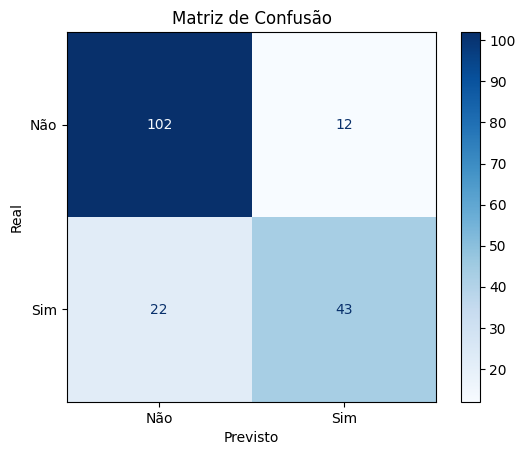

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# O teste_Y são os sim real e as previsões são os sim previstos
matriz = confusion_matrix(teste_Y, previsoes)
# Para plotar a matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Não', 'Sim'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

Para aplicar as métricas, vou usar as funções prontas do sklearn.

In [92]:
vn, fp, fn, vp = matriz.ravel()
print(f"Verdadeiros Positivos (VP): {vp}")
print(f"Verdadeiros Negativos (VN): {vn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")

acuracia = (vp + vn) / (vp + vn + fp + fn)
precisao = vp / (vp + fp)
recall = vp / (vp + fn)
f1_score = 2 * ((precisao * recall) / (precisao + recall))
print('')
print('Acurácia:', acuracia)
print('Precisão:', precisao)
print('Recall:', recall)
print('F1 Score:', f1_score)

Verdadeiros Positivos (VP): 43
Verdadeiros Negativos (VN): 102
Falsos Positivos (FP): 12
Falsos Negativos (FN): 22

Acurácia: 0.8100558659217877
Precisão: 0.7818181818181819
Recall: 0.6615384615384615
F1 Score: 0.7166666666666666
